In [1]:
import os
import re
import pandas as pd
import nilearn as nl
import numpy as np
import seaborn as sns
from nilearn.input_data import NiftiMasker
from nilearn.image.image import mean_img
from nilearn import plotting, image
from nilearn.plotting import view_img
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from nilearn.image import math_img
import time
import multiprocessing






/opt/anaconda3/lib/python3.8/site-packages/nilearn/input_data/__init__.py:27: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  warnings.warn(message, FutureWarning)


In [2]:
#f_list = [os.path.join(root,f) for root,dirs,files in os.walk(
#    '../derivatives/') for f in files if 
#          (('me1' in f) & (f.endswith('desc-preproc_bold.nii.gz')))|
#         (('me4' in f ) & (f.endswith('desc-optcom-dewarped_bold.nii.gz')))]

f_list = [os.path.join(root,f) for root,dirs,files in os.walk(
   '../derivatives/') for f in files if f.endswith('space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')]
display(f_list)

['../derivatives/fmriprep/sub-10041/func/sub-10041_task-sharedreward_acq-mb6me1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-10041/func/sub-10041_task-sharedreward_acq-mb3me1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-10041/func/sub-10041_task-sharedreward_acq-mb3me4_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-10041/func/sub-10041_task-sharedreward_acq-mb1me1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-10041/func/sub-10041_task-sharedreward_acq-mb6me4_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-10041/func/sub-10041_task-sharedreward_acq-mb1me4_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-10085/func/sub-10085_task-sharedreward_acq-mb6me1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-10085/func/sub-10085_task-sharedreward_

# Making anatomical Masks and getting files


Dataset created in /home/local/TU/tuj71575/nilearn_data/fsl



 ...done. (1 seconds, 0 min)
Extracting data from /home/local/TU/tuj71575/nilearn_data/fsl/8a69ae399b721d54ac7144f836f55c27/HarvardOxford.tgz..... done.


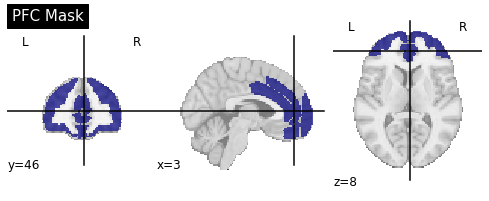

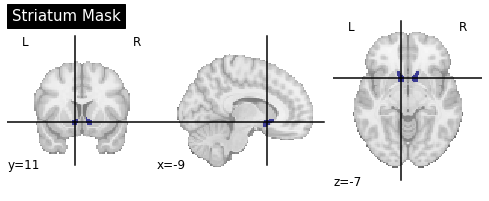

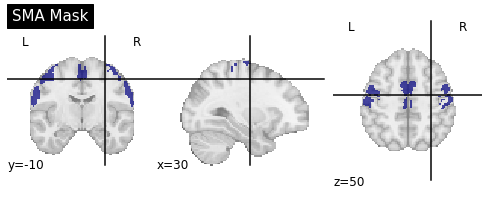

In [3]:
from nilearn import image,datasets,masking,plotting,input_data
#Striatum Mask



HO_sub=datasets.fetch_atlas_harvard_oxford(atlas_name='sub-maxprob-thr25-2mm')

keep = [idx for idx, s in enumerate(HO_sub.labels) if
        'Accumbens' in s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_sub.maps) for idx in keep]   

str_regions=image.concat_imgs(np.array(keepimg_list))
str_mask=masking.compute_background_mask(str_regions)
str_mask=NiftiMasker(mask_img=str_mask)

#MPFC mask
HO_cort=datasets.fetch_atlas_harvard_oxford(atlas_name='cort-maxprob-thr50-2mm')
keep = [idx for idx, s in enumerate(HO_cort.labels) if
        'Frontal Medial Cortex'==s or
        'Frontal Pole'==s or
        'Frontal Orbital Cortex'==s or
        'Cingulate Gyrus, anterior division'==s or
        'Paracingulate Gyrus'==s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_cort.maps) for idx in keep]                               

cort_regions=image.concat_imgs(np.array(keepimg_list))
cort_mask=masking.compute_background_mask(cort_regions)
cort_mask=NiftiMasker(mask_img=cort_mask)

#SMA mask
HO_cort=datasets.fetch_atlas_harvard_oxford(atlas_name='cort-maxprob-thr50-2mm')
keep = [idx for idx, s in enumerate(HO_cort.labels) if
        'Juxtapositional Lobule Cortex' in s or
        'Precentral Gyrus'==s or
        'Postcentral Gyrus'==s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_cort.maps) for idx in keep]                               

SMA_regions=image.concat_imgs(np.array(keepimg_list))
SMA_mask=masking.compute_background_mask(SMA_regions)
SMA_mask=NiftiMasker(mask_img=SMA_mask)

plotting.plot_roi(cort_mask.mask_img,title="PFC Mask")
plt.show()
plotting.plot_roi(str_mask.mask_img,title='Striatum Mask')
plt.show()
plotting.plot_roi(SMA_mask.mask_img,title='SMA Mask')
plt.show()

# TSNR
- Heads up these Graphs are interactive

In [4]:
data=[]
img_list=[]
for img in f_list:
    start = time.time()

    me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
    mb=int(re.search('_acq-mb(.*?)me',img).group(1))
    sub=re.search('func/sub-(.*?)_task',img).group(1)
    print('sub: %s Multiband: %s Multiecho: %s'%(sub,mb,me))
    mask = '../derivatives/fmriprep/sub-%s/func/sub-%s_task-sharedreward_acq-mb%sme%s_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz'%(sub,sub,mb,me)
    
    #nifti_masker = NiftiMasker(mask_img=mask)
    #x=nifti_masker.fit_transform(img)
    #img=nifti_masker.inverse_transform(x)
    end = time.time()
    #print("first maskfit:",end - start)
    #print(img.shape)
    
    
    # calculate mean image for the background
    from nilearn.image import math_img
    tsnr_img = image.math_img('img.mean(axis=3) / img.std(axis=3)', img=img)
    img_list.append([tsnr_img,me,mb,sub])
    y=str_mask.fit_transform(tsnr_img)
    end = time.time()
    print("STR maskfit:",end - start)
    
    z=cort_mask.fit_transform(tsnr_img)
    end = time.time()
    print("CORT maskfit:",end - start)
    data.append([sub,mb,me,np.mean(np.abs(y.flatten())),
                 np.mean(np.abs(z.flatten()))])

    end = time.time()
    print(end - start)
    

sub: 10041 Multiband: 6 Multiecho: 1
STR maskfit: 26.49857258796692
CORT maskfit: 26.845680713653564
26.846437454223633
sub: 10041 Multiband: 3 Multiecho: 1
STR maskfit: 9.62821102142334
CORT maskfit: 9.961134672164917
9.962267875671387
sub: 10041 Multiband: 3 Multiecho: 4
STR maskfit: 6.00480318069458
CORT maskfit: 6.281127452850342
6.28133225440979
sub: 10041 Multiband: 1 Multiecho: 1
STR maskfit: 3.455019950866699
CORT maskfit: 3.781745195388794
3.7824089527130127
sub: 10041 Multiband: 6 Multiecho: 4
STR maskfit: 10.694359064102173
CORT maskfit: 10.980578422546387
10.981285333633423
sub: 10041 Multiband: 1 Multiecho: 4
STR maskfit: 2.2424240112304688
CORT maskfit: 2.5228846073150635
2.523484945297241
sub: 10085 Multiband: 6 Multiecho: 1
STR maskfit: 17.81854748725891
CORT maskfit: 18.149113655090332
18.14969825744629
sub: 10085 Multiband: 3 Multiecho: 1
STR maskfit: 9.667319059371948
CORT maskfit: 10.00454592704773
10.005414724349976
sub: 10085 Multiband: 6 Multiecho: 4
STR maskfit:

STR maskfit: 9.893221139907837
CORT maskfit: 10.22752046585083
10.228269338607788
sub: 10024 Multiband: 6 Multiecho: 1
STR maskfit: 18.12247109413147
CORT maskfit: 18.45472240447998
18.45547127723694
sub: 10024 Multiband: 1 Multiecho: 4
STR maskfit: 2.2753493785858154
CORT maskfit: 2.55314564704895
2.5537517070770264


In [7]:
df['sub'].unique()

array(['10041', '10085', '10035', '10074', '10043', '10069', '10059',
       '10017', '10080', '10094', '10054', '10024'], dtype=object)

,sub,MB,ME,Region,TSNR
0,10041,6,1,Striatum,23.505663
1,10041,3,1,Striatum,23.396896
2,10041,3,4,Striatum,37.604954
3,10041,1,1,Striatum,28.502729
4,10041,6,4,Striatum,34.292160


<AxesSubplot:xlabel='MB', ylabel='TSNR'>

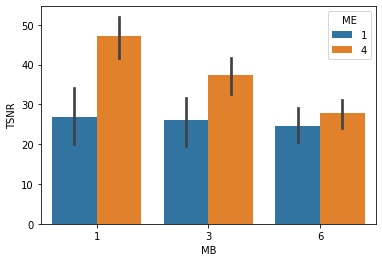

In [6]:

df=pd.DataFrame(data=data,columns=['sub','MB','ME','Striatum','MPFC'])
df=df.melt(id_vars=['sub','MB','ME'],var_name='Region',value_name='TSNR')
display(df.head())
plt_df=df[df['Region']=='Striatum']

sns.barplot(x='MB',y='TSNR',hue='ME',data=plt_df)


def collect_tsnr(img):
    start = time.time()

    me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
    mb=int(re.search('_acq-mb(.*?)me',img).group(1))
    sub=re.search('func/sub-(.*?)_task',img).group(1)
    print(sub,mb,me)
    #mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)
    
    nifti_masker = NiftiMasker(mask_strategy='background')
    x=nifti_masker.fit_transform(img)
    img=nifti_masker.inverse_transform(x)
    end = time.time()
    print("first maskfit:",end - start)
    print(img.shape)
    
    
    # calculate mean image for the background
    from nilearn.image import math_img
    tsnr_img = image.math_img('img.mean(axis=3) / img.std(axis=3)', img=img)
    img_list=[tsnr_img,me,mb,sub]
    y=str_mask.fit_transform(tsnr_img)
    print("STR maskfit:",end - start)
    z=cort_mask.fit_transform(tsnr_img)
    print("CORT maskfit:",end - start)
    data_row=[sub,mb,me,np.mean(np.abs(x.flatten())),
                 np.mean(np.abs(y.flatten())),
                 np.mean(np.abs(z.flatten()))]
    return([img_list,data_row])

    end = time.time()
    print(end - start)

def driver_func(myfunc,input_list):
    THREADS=10
    with multiprocessing.Pool(THREADS) as pool:
        results=pool.map(myfunc,input_list)
    return(results)
data=driver_func(collect_tsnr,f_list)

for img in img_list:
    plotting.plot_stat_map(img[0],
                      title="tsnr for Sub: %s ME: %s MB: %s "%(img[3],img[1],img[2]),
                      vmax=200,draw_cross=False)
    plt.show()


## Plot tsnr Maps

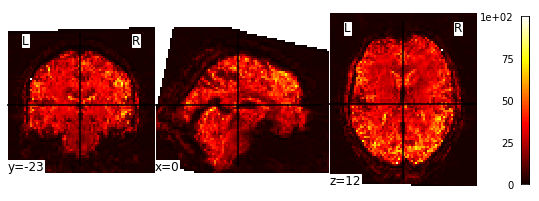

In [8]:
img=f_list[0]

#nifti_masker = NiftiMasker(mask_strategy='epi')
#x=nifti_masker.fit_transform(img)
#img=nifti_masker.inverse_transform(x)
tsnr_img = image.math_img('img.mean(axis=3) / img.std(axis=3)', img=img)
plotting.plot_stat_map(tsnr_img)

[[<nibabel.nifti1.Nifti1Image at 0x7fb510dda8b0>, 4, 3, '10017'],
 [<nibabel.nifti1.Nifti1Image at 0x7fb510e39e50>, 4, 1, '10017'],
 [<nibabel.nifti1.Nifti1Image at 0x7fb510dda6a0>, 1, 1, '10017'],
 [<nibabel.nifti1.Nifti1Image at 0x7fb510ddafa0>, 1, 3, '10017'],
 [<nibabel.nifti1.Nifti1Image at 0x7fb510ddaf10>, 4, 6, '10017'],
 [<nibabel.nifti1.Nifti1Image at 0x7fb510d4eb50>, 1, 6, '10017']]

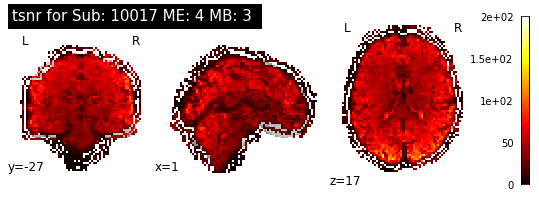

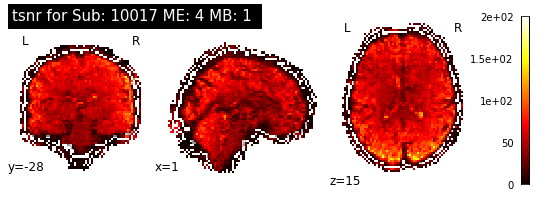

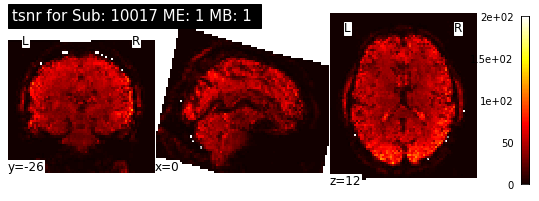

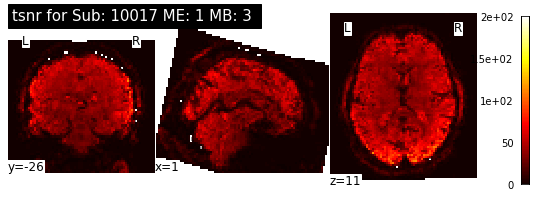

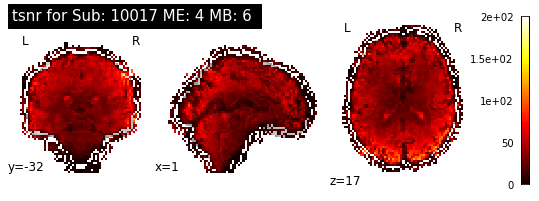

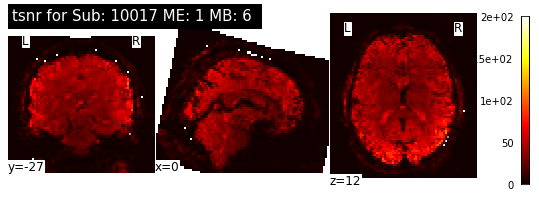

In [9]:
sub='10017'
sub_list=[img for img in img_list if img[3]==sub]
display(sub_list)
for img in sub_list:
    plotting.plot_stat_map(img[0],title="tsnr for Sub: %s ME: %s MB: %s "%(img[3],img[1],img[2]),vmax=200,draw_cross=False)
    plt.show()

# L1 Z-stats
- Heads up these Graphs are interactive

In [10]:
f_list = [os.path.join(root,f) for root,dirs,files in os.walk(
    '../derivatives/fsl/') for f in files if ('zstat' in f) & f.endswith('.nii.gz')]#  ('stats' in root) &if ('/stats/zstat' in f) & (f.endswith('nii.gz'))]
f_list=[f for f in f_list if ('stats/zstat' in f) & ('L1_task' in f)]
display(f_list)

['../derivatives/fsl/L3_model-2_task-sharedreward_mb3me4_fixedeffects.gfeat/cope15.feat/stats/zstat2.nii.gz',
 '../derivatives/fsl/L3_model-2_task-sharedreward_mb3me4_fixedeffects.gfeat/cope15.feat/stats/zstat1.nii.gz',
 '../derivatives/fsl/L3_model-2_task-sharedreward_mb3me4_fixedeffects.gfeat/cope14.feat/stats/zstat2.nii.gz',
 '../derivatives/fsl/L3_model-2_task-sharedreward_mb3me4_fixedeffects.gfeat/cope14.feat/stats/zstat1.nii.gz',
 '../derivatives/fsl/L3_model-2_task-sharedreward_mb3me4_fixedeffects.gfeat/cope11.feat/stats/zstat2.nii.gz',
 '../derivatives/fsl/L3_model-2_task-sharedreward_mb3me4_fixedeffects.gfeat/cope11.feat/stats/zstat1.nii.gz',
 '../derivatives/fsl/L3_model-2_task-sharedreward_mb3me4_fixedeffects.gfeat/cope10.feat/stats/zstat2.nii.gz',
 '../derivatives/fsl/L3_model-2_task-sharedreward_mb3me4_fixedeffects.gfeat/cope10.feat/stats/zstat1.nii.gz',
 '../derivatives/fsl/L3_model-2_task-sharedreward_mb3me4_fixedeffects.gfeat/cope13.feat/stats/zstat2.nii.gz',
 '../deriv

In [11]:

def collect_zstats(img):
    zstat=int(re.search('thresh_zstat(.*).nii.gz',img).group(1))
    if zstat>10:
        me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
        mb=int(re.search('_acq-mb(.*?)me',img).group(1))
        sub=re.search('fsl/sub-(.*?)/L1',img).group(1)
        mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)

        nifti_masker = NiftiMasker(mask_strategy='background')
        x=nifti_masker.fit_transform(img)
        img=nifti_masker.inverse_transform(x)

        # calculate mean image for the background
    
        x=nifti_masker.fit_transform(img)
        y=str_mask.fit_transform(img)
        z=cort_mask.fit_transform(img)
        
        img_row=[str_mask.inverse_transform(y),img,zstat,me,mb,sub]

        data_row=[sub,mb,me,zstat,np.mean(np.abs(x.flatten())),
                     np.mean(np.abs(y.flatten())),
                     np.mean(np.abs(z.flatten()))]
        return(data_row)

def driver_func(myfunc,input_list):
    THREADS=4
    with multiprocessing.Pool(THREADS) as pool:
        data_res=[pool.apply_async(myfunc,p) for p in input_list]
        
driver_func(collect_zstats,f_list)

In [12]:
data=[]
img_list=[]
for img in f_list:
    
    zstat=int(re.search('zstat(.*).nii.gz',img).group(1))
    if zstat in[5,7,8,9]:
        me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
        mb=int(re.search('_acq-mb(.*?)me',img).group(1))
        sub=re.search('fsl/sub-(.*?)/L1',img).group(1)
        #mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)

        #nifti_masker = NiftiMasker(mask_strategy='background')
        x=cort_mask.fit_transform(img)
        img=cort_mask.inverse_transform(x)

        # calculate mean image for the background
    
        #x=nifti_masker.fit_transform(img)
        #y=str_mask.fit_transform(img)
        z=cort_mask.fit_transform(img)
        
        #img_list.append([str_mask.inverse_transform(y),img,zstat,me,mb,sub])

        data.append([sub,mb,me,zstat,np.mean(z.flatten())])

,sub,acq,Reward,contrast,MB,ME,zstat
0,10017,11,Punishment,6.5,1.0,1.0,-0.338099
1,10017,11,Reward,8.0,1.0,1.0,-0.026398
2,10017,14,Punishment,6.5,1.0,4.0,0.013210
3,10017,14,Reward,8.0,1.0,4.0,0.027458
4,10017,31,Punishment,6.5,3.0,1.0,0.323935


,sub,acq,Reward,contrast,MB,ME,zstat
0,10017,11,Punishment,6.5,1.0,1.0,-0.338099
1,10017,11,Reward,8.0,1.0,1.0,-0.026398
2,10017,14,Punishment,6.5,1.0,4.0,0.013210
3,10017,14,Reward,8.0,1.0,4.0,0.027458
4,10017,31,Punishment,6.5,3.0,1.0,0.323935


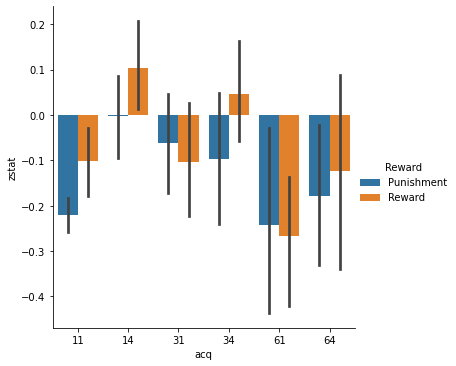

In [27]:
df=pd.DataFrame(data=data,columns=['sub','MB','ME','contrast','Striatum'])
df=df.melt(id_vars=['contrast','sub','MB','ME'],var_name='Region',value_name='zstat')
df['acq']=df["MB"].astype(str) + df["ME"].astype(str)
df['condition'] = df['contrast'].replace({5:'Computer Punishment',
                                          7:'Computer Reward',
                                          8:'Stranger Punishment',
                                          9:'Stranger Reward'})
df=df[~df['sub'].isin(['10041','10069','10085','10094'])]
df[['Player','Reward']] = df.condition.str.split(expand=True)
plt_df=df[df['Region']=='Striatum']

plt_df=df.groupby(by=['sub','acq','Reward']).mean().reset_index()

display(plt_df.head())
g=sns.catplot(x='acq',y='zstat',hue='Reward',kind='bar',data=plt_df,ci=85,
              dodge=True,order=['11','14','31','34','61','64'])
g.savefig('RF1-zstat.pdf')
plt_df.head()

In [40]:
rew=plt_df[plt_df['Reward']=='Reward'].reset_index()
pun=plt_df[plt_df['Reward']=='Punishment'].reset_index()
display(pun['zstat']-rew['zstat'])


0    -0.311701
1    -0.014248
2    -0.097165
3     0.122832
4     0.071282
5    -0.231759
6     0.087881
7    -0.339658
8     0.019019
9    -0.306799
10    0.417288
11   -0.093561
12   -0.148739
13   -0.021433
14    0.017958
15   -0.039430
16   -0.109901
17   -0.066056
18    0.037293
19    0.211510
20   -0.331944
21   -0.334626
22    0.255118
23   -0.278803
24   -0.289705
25   -0.026002
26    0.508110
27   -0.273155
28    0.349290
29   -0.000643
30   -0.143592
31   -0.262460
32    0.191600
33    0.100207
34    0.189832
35   -0.147144
36   -0.074329
37   -0.390531
38    0.087915
39   -0.352313
40   -0.674006
41    0.400549
42   -0.100608
43    0.000709
44   -0.064467
45   -0.071281
46   -0.311240
47   -0.023493
Name: zstat, dtype: float64

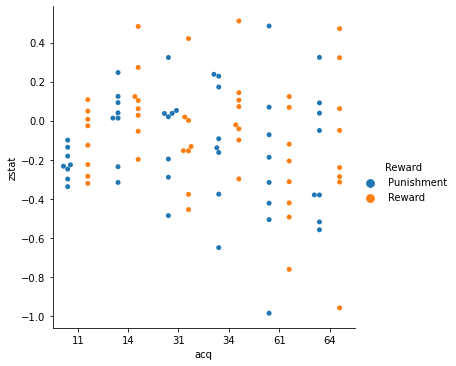

In [22]:
mean_df=plt_df.groupby(by=['sub','acq','Reward']).mean()
mean_df=mean_df.reset_index()
sns.catplot(x='acq',y='zstat',hue='Reward',kind='swarm',data=mean_df,dodge=True,order=['11','14','31','34','61','64'])
